## Koopman Cart Pole Plotting

This notebook loads the learned Koopman eigenvalues associated with different RL models, their rewards, and the reconstruction errors of the models. These are then plotted

In [99]:
import os
os.chdir('/Users/wredman/Documents/GitHub/Koopman4RL/')

import numpy as np
import matplotlib.pyplot as plt

### Loading data

In [159]:
n_init = 25
task = "LunarLander-v3"   #"CartPole-v1" #"Acrobot-v1" #"LunarLander-v3"
RL_algos = ["PPO", "A2C"]
n_algos = len(RL_algos)
training_epochs = [0, 10000, 20000, 30000, 40000, 50000] #[0, 200, 400, 600, 800, 1000] #[0, 2000, 4000, 6000, 8000, 10000] #[0, 20000, 40000, 60000, 80000, 100000]
training_save_path = '/Users/wredman/Documents/GitHub/Koopman4RL/Models/'
save_fig = True

In [160]:
max_eig = np.zeros((n_algos, len(training_epochs), n_init))
average_reward = np.zeros((n_algos, len(training_epochs), n_init))
average_reconstruction_MSE = np.zeros((n_algos, len(training_epochs), n_init))

for algo in range(n_algos):
    for init in range(n_init):
        for tt in range(len(training_epochs)):
            eigs = np.load(training_save_path + RL_algos[algo] + "/" + task + "_init-" + str(init) + "_epochs-" + str(training_epochs[tt]) + "-eigenvalues.npy")
            max_eig[algo, tt, init] = np.max(np.abs(eigs)) #np.mean(np.abs(eigs)) #np.abs(1 - np.max(np.real(eigs))

            rewards = np.load(training_save_path + RL_algos[algo] + "/" + task + "_init-" + str(init) + "_epochs-" + str(training_epochs[tt]) + "-rewards.npy")
            average_reward[algo, tt, init] = np.median(rewards)

            reconstruction_residuals = np.load(training_save_path + RL_algos[algo] + "/" + task + "_init-" + str(init) + "_epochs-" + str(training_epochs[tt]) + "-reconstruction-residuals.npy")
            average_reconstruction_MSE[algo, tt, init] = np.median(np.mean((reconstruction_residuals**2), axis = 0))

In [161]:
control_rank = np.zeros((n_algos, len(training_epochs), n_init))
average_singular_value = np.zeros((n_algos, len(training_epochs), n_init))

for algo in range(n_algos):
    for init in range(n_init):
        for tt in range(len(training_epochs)):
            A = np.load(training_save_path + RL_algos[algo] + "/" + task + "_init-" + str(init) + "_epochs-" + str(training_epochs[tt]) + "-A_tilde.npy")
            B = np.load(training_save_path + RL_algos[algo] + "/" + task + "_init-" + str(init) + "_epochs-"  + str(training_epochs[tt]) + "-B_hat.npy")

            C = B
            for ii in range(1, np.shape(A)[0]):
                C = np.concatenate((C, A**ii @ B), 1)
            control_rank[algo, tt, init] = np.linalg.matrix_rank(C) / np.shape(A)[0]

/var/folders/vc/hg24zlnx53l5v637yk9tlnx80000gn/T/ipykernel_45747/1459082510.py:12: RuntimeWarning: divide by zero encountered in matmul
  C = np.concatenate((C, A**ii @ B), 1)
/var/folders/vc/hg24zlnx53l5v637yk9tlnx80000gn/T/ipykernel_45747/1459082510.py:12: RuntimeWarning: overflow encountered in matmul
  C = np.concatenate((C, A**ii @ B), 1)
/var/folders/vc/hg24zlnx53l5v637yk9tlnx80000gn/T/ipykernel_45747/1459082510.py:12: RuntimeWarning: invalid value encountered in matmul
  C = np.concatenate((C, A**ii @ B), 1)


### Plotting

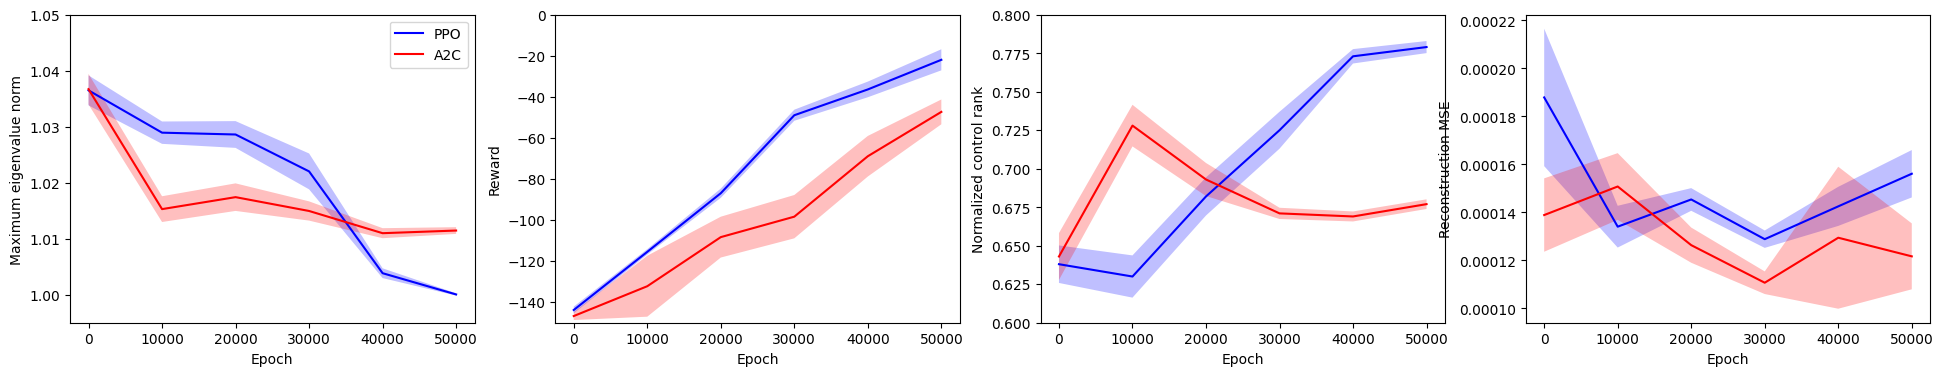

In [162]:
results_save_path = '/Users/wredman/Documents/GitHub/Koopman4RL/results/'

colors = ['b', 'r', 'g']

plt.figure(figsize=(24, 4))

plt.subplot(1, 4, 1)
for algo in range(n_algos):
    plt.fill_between(training_epochs, np.mean(max_eig[algo, :, :], axis = 1) - np.std(max_eig[algo, :, :], axis = 1) / np.sqrt(n_init), np.mean(max_eig[algo, :, :], axis = 1) + np.std(max_eig[algo, :, :], axis = 1) / np.sqrt(n_init), alpha = 0.25, facecolor = colors[algo])
    plt.plot(training_epochs, np.mean(max_eig[algo, :, :], axis = 1), '-', color = colors[algo],  label = RL_algos[algo])
plt.xlabel('Epoch')
plt.ylabel('Maximum eigenvalue norm')
plt.legend()
plt.ylim([0.995, 1.05])

plt.subplot(1, 4, 2)
for algo in range(n_algos):
    plt.fill_between(training_epochs, np.mean(average_reward[algo, :, :], axis = 1) - np.std(average_reward[algo, :, :], axis = 1) / np.sqrt(n_init), np.mean(average_reward[algo, :, :], axis = 1) + np.std(average_reward[algo, :, :], axis = 1) / np.sqrt(n_init), alpha = 0.25, facecolor = colors[algo])
    plt.plot(training_epochs, np.mean(average_reward[algo, :, :], axis = 1), '-', color = colors[algo])
plt.xlabel('Epoch')
plt.ylabel('Reward')
plt.ylim(-150, 0)

plt.subplot(1, 4, 3)
for algo in range(n_algos):
    plt.fill_between(training_epochs, np.mean(control_rank[algo, :, :], axis = 1) - np.std(control_rank[algo, :, :], axis = 1) / np.sqrt(n_init), np.mean(control_rank[algo, :, :], axis = 1) + np.std(control_rank[algo, :, :], axis = 1) / np.sqrt(n_init), alpha = 0.25, facecolor = colors[algo])
    plt.plot(training_epochs, np.mean(control_rank[algo, :, :], axis = 1), '-', color = colors[algo])
plt.xlabel('Epoch')
plt.ylabel('Normalized control rank')
plt.ylim(0.6, 0.8)

plt.subplot(1, 4, 4)
for algo in range(n_algos):
    plt.fill_between(training_epochs, np.mean(average_reconstruction_MSE[algo, :, :], axis = 1) - np.std(average_reconstruction_MSE[algo, :, :], axis = 1) / np.sqrt(n_init), np.mean(average_reconstruction_MSE[algo, :, :], axis = 1) + np.std(average_reconstruction_MSE[algo, :, :], axis = 1) / np.sqrt(n_init), alpha = 0.25, facecolor = colors[algo])
    plt.plot(training_epochs, np.mean(average_reconstruction_MSE[algo, :, :], axis = 1), '-', color = colors[algo])
plt.xlabel('Epoch')
plt.ylabel('Reconstruction MSE')

if save_fig:
    plt.savefig(results_save_path + task + '-summary-results.png')
    plt.savefig(results_save_path + task + '-summary-results.svg', format='svg')

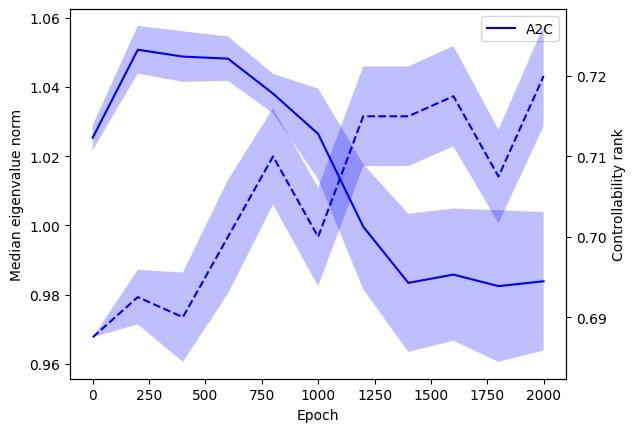

In [135]:
fig, ax1 = plt.subplots()

ax1.set_xlabel('Epoch')
ax1.set_ylabel('Median eigenvalue norm')
for algo in range(n_algos):
    ax1.fill_between(training_epochs, np.mean(max_eig[algo, :, :], axis = 1) - np.std(max_eig[algo, :, :], axis = 1) / np.sqrt(n_init), np.mean(max_eig[algo, :, :], axis = 1) + np.std(max_eig[algo, :, :], axis = 1) / np.sqrt(n_init), alpha = 0.25, facecolor = colors[algo])
    ax1.plot(training_epochs, np.mean(max_eig[algo, :, :], axis = 1), '-', color = colors[algo],  label = RL_algos[algo])
    ax1.legend()

ax2 = ax1.twinx()  # instantiate a second Axes that shares the same x-axis
ax2.set_ylabel('Controllability rank')

for algo in range(n_algos):
    ax2.fill_between(training_epochs, np.mean(control_rank[algo, :, :], axis = 1) - np.std(control_rank[algo, :, :], axis = 1) / np.sqrt(n_init), np.mean(control_rank[algo, :, :], axis = 1) + np.std(control_rank[algo, :, :], axis = 1) / np.sqrt(n_init), alpha = 0.25, facecolor = colors[algo])
    ax2.plot(training_epochs, np.mean(control_rank[algo, :, :], axis = 1), '--', color = colors[algo])

if save_fig:
    plt.savefig(results_save_path + task + '-controllability-eigenvalue-norm-hidden-progress-measure.png')
    plt.savefig(results_save_path + task + '-controllability-eigenvalue-norm-hidden-progress-measure.svg', format='svg')
